# Phase 2: RNN Experiments

Building on Phase 1's LS baselines, we now test two improvements to the closed-loop vanilla RNN:

1. **Experiment 2a — LR Scheduler**: Best previous config (CL ReLU, h=64, transformed z-coords) but with `ReduceLROnPlateau` scheduler. The idea is that the flat LR=0.0001 may stop making progress — a scheduler can lower it when the loss plateaus.

2. **Experiment 2b — Physics-Informed RNN**: Feed the LS-identified matrices (D, E1, E2) as additional input features. The RNN gets both the raw state+force AND the linear model's "opinion" of the next state, so it only needs to learn the *nonlinear residual*.

Both experiments train on seed=42 data and evaluate autoregressively on seed=99 (unseen test data), with NSE computed for direct comparison against the LS baselines from Phase 1.

In [17]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import os

# Navigate to project root
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
print(f"Working directory: {os.getcwd()}")
print(f"CUDA available: {torch.cuda.is_available()}")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Working directory: c:\Users\obedg\Downloads\RNN Honours Rotation
CUDA available: True
Using device: cuda


---
## Load Data

We use the **transformed z-coordinates** (relative + absolute) since that was the best-performing coordinate system from Phase 1. We load both train (seed=42) and test (seed=99) for the original ±1.0 springs.

In [18]:
# --- Load TRAIN data (seed=42, original ±1.0 springs, transformed z) ---
train_data = np.load("data/transformed_simulation_data.npz")
z_train = train_data['z_vals']
u_train = np.array(train_data['u_plot'])

# --- Load TEST data (seed=99, original ±1.0 springs, transformed z) ---
test_data = np.load("data/test_transformed_simulation_data.npz")
z_test = test_data['z_vals']
u_test = np.array(test_data['u_plot'])

# --- Load LS matrices for physics-informed experiment ---
ls_mats = np.load("data/ls_matrices_original_transformed.npz")
D_ls = ls_mats['D']    # (4, 4)
E1_ls = ls_mats['E1']  # (4, 1)
E2_ls = ls_mats['E2']  # (4, 1)

print(f"Train: z={z_train.shape}, u={u_train.shape}")
print(f"Test: z={z_test.shape}, u={u_test.shape}")
print(f"LS matrices: D={D_ls.shape}, E1={E1_ls.shape}, E2={E2_ls.shape}")

# --- Normalize using TRAIN statistics only ---
z_mean, z_std = z_train.mean(axis=0), z_train.std(axis=0)
u_mean, u_std = u_train.mean(), u_train.std()

z_train_norm = (z_train - z_mean) / (z_std + 1e-8)
u_train_norm = (u_train - u_mean) / (u_std + 1e-8)
z_test_norm = (z_test - z_mean) / (z_std + 1e-8)   # normalize test with TRAIN stats
u_test_norm = (u_test - u_mean) / (u_std + 1e-8)

# Convert to tensors
Z_train = torch.tensor(z_train_norm, dtype=torch.float32)
U_train = torch.tensor(u_train_norm, dtype=torch.float32).unsqueeze(1)
Z_test = torch.tensor(z_test_norm, dtype=torch.float32)
U_test = torch.tensor(u_test_norm, dtype=torch.float32).unsqueeze(1)

print(f"\nNormalized tensors:")
print(f"Z_train: {Z_train.shape}, U_train: {U_train.shape}")
print(f"Z_test:  {Z_test.shape},  U_test:  {U_test.shape}")

Train: z=(20000, 4), u=(20000,)
Test: z=(20000, 4), u=(20000,)
LS matrices: D=(4, 4), E1=(4, 1), E2=(4, 1)

Normalized tensors:
Z_train: torch.Size([20000, 4]), U_train: torch.Size([20000, 1])
Z_test:  torch.Size([20000, 4]),  U_test:  torch.Size([20000, 1])


---
## RNN Architecture & Helper Functions

Same hand-coded Elman RNN as all previous notebooks:
- $h_k = \text{ReLU}(h_{k-1} \cdot W_{hh} + \text{input}_k \cdot W_{uh} + b_h)$
- $\hat{z}_{k+1} = h_k \cdot W_{hx} + b_x$

During **training**: teacher forcing (feed ground truth states).  
During **evaluation**: autoregressive (feed own predictions back).

In [19]:
class RNN(nn.Module):
    """Hand-coded Elman RNN (same architecture as all previous notebooks)."""
    def __init__(self, input_size, hidden_size, output_size):
        super(RNN, self).__init__()
        self.hidden_size = hidden_size
        
        # Memory update weights
        self.W_hh = nn.Parameter(torch.randn(hidden_size, hidden_size) * 0.1)
        self.W_uh = nn.Parameter(torch.randn(input_size, hidden_size) * 0.1)
        self.b_h = nn.Parameter(torch.zeros(hidden_size))
        
        # State prediction weights
        self.W_hx = nn.Parameter(torch.randn(hidden_size, output_size) * 0.1)
        self.b_x = nn.Parameter(torch.zeros(output_size))
    
    def forward(self, combined_u_seq):
        seq_len = combined_u_seq.shape[0]
        h_k = torch.zeros(self.hidden_size, device=combined_u_seq.device)
        y_pred = []
        
        for k in range(seq_len):
            step_data = combined_u_seq[k]
            h_k = torch.relu(h_k @ self.W_hh + step_data @ self.W_uh + self.b_h)
            y_k = h_k @ self.W_hx + self.b_x
            y_pred.append(y_k)
        
        return torch.stack(y_pred)


def compute_nse(y_true, y_pred):
    """Normalized Simulation Error = ||y_true - y_pred|| / ||y_true||"""
    return np.linalg.norm(y_true - y_pred) / (np.linalg.norm(y_true) + 1e-10)


def train_rnn(model, Z_data, U_data, n_epochs=1000, seq_len=100, batch_size=16, 
              lr=0.01, use_scheduler=False, print_every=10):
    """
    Train a closed-loop RNN with teacher forcing.
    Returns: loss_history, lr_history
    """
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    scheduler = None
    if use_scheduler:
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min', factor=0.5, patience=50, 
            min_lr=1e-6, verbose=False
        )
    
    loss_history = []
    lr_history = []
    
    for epoch in range(n_epochs):
        model.train()
        optimizer.zero_grad()
        batch_loss = 0
        
        for _ in range(batch_size):
            start_idx = np.random.randint(0, len(U_data) - seq_len - 1)
            end_idx = start_idx + seq_len
            
            U_curr = U_data[start_idx:end_idx].to(device)
            Z_curr = Z_data[start_idx:end_idx].to(device)
            combined_input = torch.cat((Z_curr, U_curr), dim=1)
            
            Z_target = Z_data[start_idx + 1: end_idx + 1].to(device)
            
            Z_pred_chunk = model(combined_input)
            loss = criterion(Z_pred_chunk, Z_target) / batch_size
            loss.backward()
            batch_loss += loss.item() * batch_size
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        avg_loss = batch_loss / batch_size
        loss_history.append(avg_loss)
        lr_history.append(optimizer.param_groups[0]['lr'])
        
        if scheduler is not None:
            scheduler.step(avg_loss)
        
        if (epoch + 1) % print_every == 0:
            current_lr = optimizer.param_groups[0]['lr']
            print(f"Epoch {epoch+1}/{n_epochs}, Loss: {avg_loss:.6f}, LR: {current_lr:.2e}")
    
    return loss_history, lr_history


def evaluate_autoregressive(model, Z_data, U_data, z_ground_truth, input_size):
    """
    Run the model autoregressively (closed-loop) over the full trajectory.
    Returns: predictions in original (un-normalized) coordinates.
    """
    model.eval()
    with torch.no_grad():
        preds = []
        current_state = Z_data[0].to(device)
        h_k = torch.zeros(model.hidden_size, device=device)
        
        for k in range(len(U_data)):
            u_k = U_data[k].to(device)
            step_data = torch.cat((current_state, u_k))
            
            h_k = torch.relu(h_k @ model.W_hh + step_data @ model.W_uh + model.b_h)
            next_state_pred = h_k @ model.W_hx + model.b_x
            preds.append(next_state_pred)
            current_state = next_state_pred
        
        Y_pred_norm = torch.stack(preds)
        Y_pred = Y_pred_norm.cpu().numpy() * z_std + z_mean
    
    return Y_pred


def plot_results(z_true_train, y_pred_train, z_true_test, y_pred_test, 
                 nse_train, nse_test, title):
    """Standard 2x2 plot: train left, test right, z1 top, z3 bottom."""
    fig, axes = plt.subplots(2, 2, figsize=(16, 8))
    fig.suptitle(title, fontsize=14)
    
    axes[0,0].plot(z_true_train[:, 0], 'k-', lw=1, label='Ground Truth')
    axes[0,0].plot(y_pred_train[:, 0], 'r--', lw=1, label='RNN Prediction')
    axes[0,0].set_title(f"TRAIN — z1 rel pos (NSE={nse_train[0]:.4f})")
    axes[0,0].legend(); axes[0,0].grid(True)
    
    axes[1,0].plot(z_true_train[:, 2], 'k-', lw=1, label='Ground Truth')
    axes[1,0].plot(y_pred_train[:, 2], 'g--', lw=1, label='RNN Prediction')
    axes[1,0].set_title(f"TRAIN — z3 abs pos M2 (NSE={nse_train[1]:.4f})")
    axes[1,0].legend(); axes[1,0].grid(True); axes[1,0].set_xlabel('Time Steps')
    
    axes[0,1].plot(z_true_test[:, 0], 'k-', lw=1, label='Ground Truth')
    axes[0,1].plot(y_pred_test[:, 0], 'r--', lw=1, label='RNN Prediction')
    axes[0,1].set_title(f"TEST — z1 rel pos (NSE={nse_test[0]:.4f})")
    axes[0,1].legend(); axes[0,1].grid(True)
    
    axes[1,1].plot(z_true_test[:, 2], 'k-', lw=1, label='Ground Truth')
    axes[1,1].plot(y_pred_test[:, 2], 'g--', lw=1, label='RNN Prediction')
    axes[1,1].set_title(f"TEST — z3 abs pos M2 (NSE={nse_test[1]:.4f})")
    axes[1,1].legend(); axes[1,1].grid(True); axes[1,1].set_xlabel('Time Steps')
    
    plt.tight_layout()
    plt.show()

print("RNN class and helper functions defined.")

RNN class and helper functions defined.


---
# Experiment 2a: CL ReLU RNN (h=64) + ReduceLROnPlateau

Same config as the best previous run (`CL_RNN_Transformed_data.ipynb` with h=64), but now with a learning rate scheduler that halves the LR when loss plateaus for 50 epochs. This should help the model converge to a lower final loss.

Config:
- `input_size=5` (4 z-states + 1 force)
- `hidden_size=64`, ReLU activation
- `Adam lr=0.0001` → `ReduceLROnPlateau(factor=0.5, patience=50, min_lr=1e-6)`
- `batch_size=16, seq_len=100, 1000 epochs, grad clip=1.0`

In [21]:
# --- Train Experiment 2a ---
print("2a: CL ReLU RNN h=64 + ReduceLROnPlateau")

model_2a = RNN(input_size=5, hidden_size=64, output_size=4).to(device)
loss_2a, lr_2a = train_rnn(
    model_2a, Z_train, U_train, 
    n_epochs=1000, seq_len=100, batch_size=16, lr=0.01,
    use_scheduler=True, print_every=10
)

print(f"\nFinal loss: {loss_2a[-1]:.6f}")
print(f"Final LR: {lr_2a[-1]:.2e}")
print(f"Min loss achieved: {min(loss_2a):.6f}")

2a: CL ReLU RNN h=64 + ReduceLROnPlateau
Epoch 10/1000, Loss: 0.117631, LR: 1.00e-02
Epoch 20/1000, Loss: 0.045425, LR: 1.00e-02
Epoch 30/1000, Loss: 0.047665, LR: 1.00e-02
Epoch 40/1000, Loss: 0.028038, LR: 1.00e-02
Epoch 50/1000, Loss: 0.032857, LR: 1.00e-02
Epoch 60/1000, Loss: 0.008132, LR: 1.00e-02
Epoch 70/1000, Loss: 0.011953, LR: 1.00e-02
Epoch 80/1000, Loss: 0.009741, LR: 1.00e-02
Epoch 90/1000, Loss: 0.008917, LR: 1.00e-02
Epoch 100/1000, Loss: 0.002807, LR: 1.00e-02
Epoch 110/1000, Loss: 0.004674, LR: 1.00e-02
Epoch 120/1000, Loss: 0.002004, LR: 1.00e-02
Epoch 130/1000, Loss: 0.001515, LR: 1.00e-02
Epoch 140/1000, Loss: 0.002511, LR: 1.00e-02
Epoch 150/1000, Loss: 0.002126, LR: 1.00e-02
Epoch 160/1000, Loss: 0.002165, LR: 1.00e-02
Epoch 170/1000, Loss: 0.001968, LR: 1.00e-02
Epoch 180/1000, Loss: 0.001997, LR: 1.00e-02
Epoch 190/1000, Loss: 0.000842, LR: 1.00e-02
Epoch 200/1000, Loss: 0.001359, LR: 1.00e-02
Epoch 210/1000, Loss: 0.002403, LR: 1.00e-02
Epoch 220/1000, Loss: 0

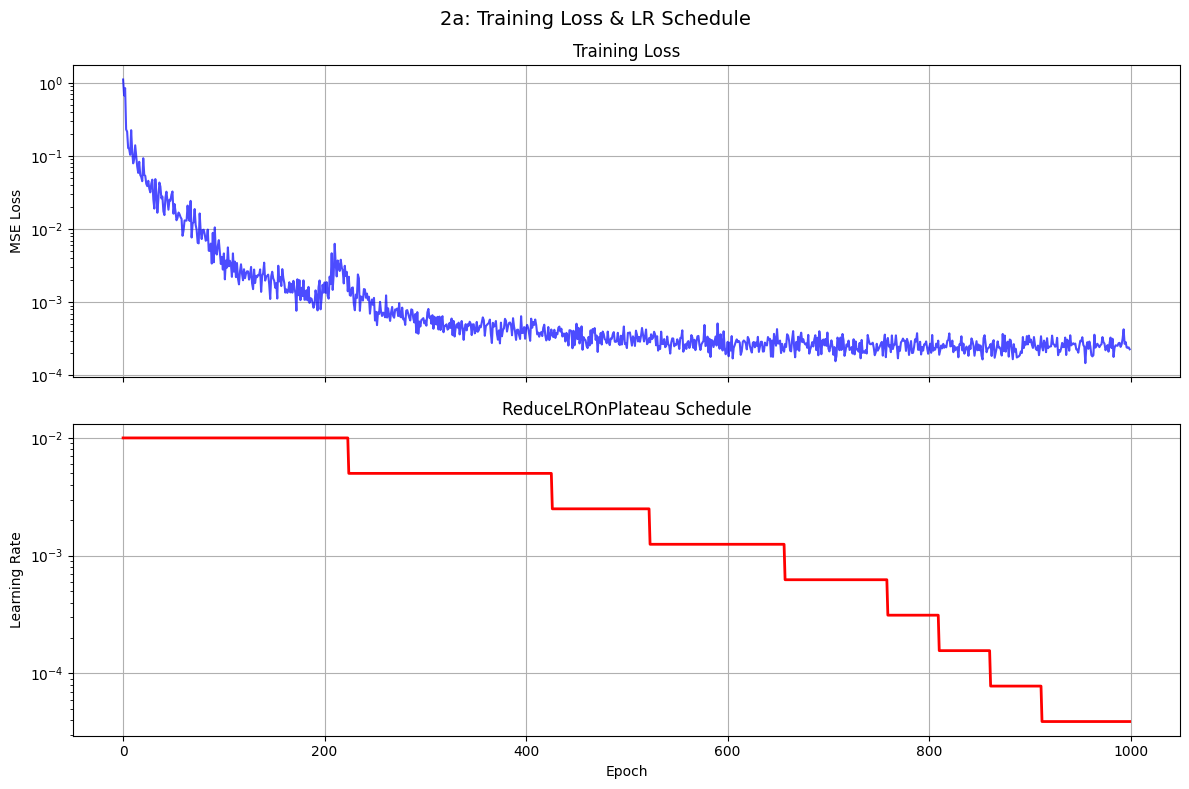

In [22]:
# Plot training loss + LR schedule
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
fig.suptitle("2a: Training Loss & LR Schedule", fontsize=14)

ax1.plot(loss_2a, 'b-', alpha=0.7)
ax1.set_ylabel('MSE Loss')
ax1.set_title('Training Loss')
ax1.grid(True)
ax1.set_yscale('log')

ax2.plot(lr_2a, 'r-', lw=2)
ax2.set_ylabel('Learning Rate')
ax2.set_xlabel('Epoch')
ax2.set_title('ReduceLROnPlateau Schedule')
ax2.grid(True)
ax2.set_yscale('log')

plt.tight_layout()
plt.show()

Evaluating 2a autoregressively
2a TRAIN NSE — z1: 1.7476, z3: 1.7655
2a TEST  NSE — z1: 1.7450,  z3: 1.5516


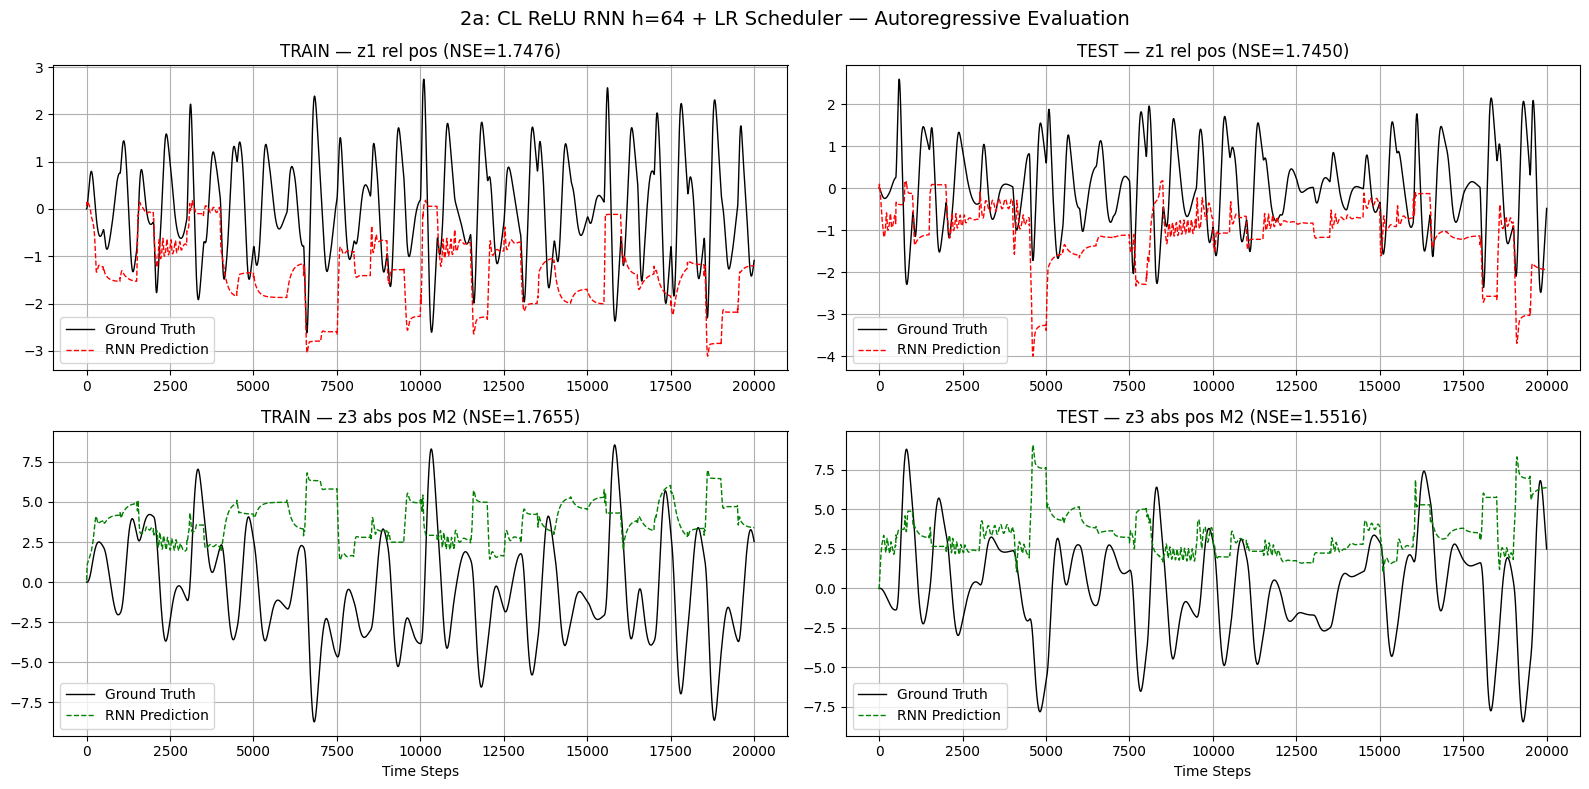

In [23]:
# --- Evaluate 2a: Autoregressive rollout on TRAIN and TEST ---
print("Evaluating 2a autoregressively")

# TRAIN rollout
y_pred_2a_train = evaluate_autoregressive(model_2a, Z_train, U_train, z_train, input_size=5)
nse_2a_train_z1 = compute_nse(z_train[:, 0], y_pred_2a_train[:, 0])
nse_2a_train_z3 = compute_nse(z_train[:, 2], y_pred_2a_train[:, 2])

# TEST rollout
y_pred_2a_test = evaluate_autoregressive(model_2a, Z_test, U_test, z_test, input_size=5)
nse_2a_test_z1 = compute_nse(z_test[:, 0], y_pred_2a_test[:, 0])
nse_2a_test_z3 = compute_nse(z_test[:, 2], y_pred_2a_test[:, 2])

print(f"2a TRAIN NSE — z1: {nse_2a_train_z1:.4f}, z3: {nse_2a_train_z3:.4f}")
print(f"2a TEST  NSE — z1: {nse_2a_test_z1:.4f},  z3: {nse_2a_test_z3:.4f}")

plot_results(z_train, y_pred_2a_train, z_test, y_pred_2a_test,
             (nse_2a_train_z1, nse_2a_train_z3), (nse_2a_test_z1, nse_2a_test_z3),
             "2a: CL ReLU RNN h=64 + LR Scheduler — Autoregressive Evaluation")

---
# Experiment 2b: Physics-Informed RNN (LS Prediction as Extra Input)

Feed the LS model's one-step prediction $\hat{z}_{k+1}^{LS} = D \cdot z_k + E_1 \cdot u_{k+1} + E_2 \cdot u_k$ as additional input features to the RNN.

This way the RNN gets **9 input features**:
- 4 current z-states (normalized)
- 1 force u_k (normalized)  
- 4 LS-predicted next states (normalized with same stats)

The idea is that the LS model already captures the linear dynamics well, so the RNN only needs to learn the **nonlinear residual** — the part the linear model can't get right. This is essentially a residual learning / boosting approach.

We also add the LR scheduler here since it was tested in 2a.

In [40]:
# --- Precompute LS predictions for all timesteps ---
# z_hat_{k+1} = D * z_k + E1 * u_{k+1} + E2 * u_k  (in ORIGINAL coordinates)

def rollout_ls(D, E1, E2, y0, u_plot, N):
    y_pred = np.zeros((N, 4))
    y_pred[0] = y0
    for k in range(N - 1):
        x_k = y_pred[k].reshape(4, 1)
        u_next = u_plot[k+1] if k+1 < N else u_plot[k]
        y_pred[k+1] = (D @ x_k + E1 * u_next + E2 * u_plot[k]).flatten()
    return y_pred

ls_rollout_train = rollout_ls(D_ls, E1_ls, E2_ls, z_train[0], u_train, len(u_train))
ls_rollout_test = rollout_ls(D_ls, E1_ls, E2_ls, z_test[0], u_test, len(u_test))

LS_train = torch.tensor((ls_rollout_train - z_mean)/(z_std+1e-8), dtype=torch.float32)
LS_test = torch.tensor((ls_rollout_test - z_mean)/(z_std+1e-8), dtype=torch.float32)

print(f"LS prediction tensors: train={LS_train.shape}, test={LS_test.shape}")
print(f"\nPhysics-informed input at each step: [z1,z2,z3,z4, u, ls_z1,ls_z2,ls_z3,ls_z4] = 9 features")

LS prediction tensors: train=torch.Size([20000, 4]), test=torch.Size([20000, 4])

Physics-informed input at each step: [z1,z2,z3,z4, u, ls_z1,ls_z2,ls_z3,ls_z4] = 9 features


In [41]:
# --- Train Experiment 2b ---
print("2b: Physics-Informed RNN (input_size=9, h=64)")

model_2b = RNN(input_size=9, hidden_size=64, output_size=4).to(device)
criterion = nn.MSELoss()
optimizer_2b = optim.Adam(model_2b.parameters(), lr=0.01)
scheduler_2b = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_2b, mode='min', factor=0.5, patience=50, min_lr=1e-6, verbose=False
)

n_epochs = 1000
seq_len = 100
batch_size = 16
loss_2b = []
lr_2b = []

for epoch in range(n_epochs):
    model_2b.train()
    optimizer_2b.zero_grad()
    batch_loss = 0
    
    for _ in range(batch_size):
        start_idx = np.random.randint(0, len(U_train) - seq_len - 1)
        end_idx = start_idx + seq_len
        
        Z_curr = Z_train[start_idx:end_idx].to(device)
        U_curr = U_train[start_idx:end_idx].to(device)
        # FIX: shift LS by +1 so it's the FORWARD-LOOKING prediction of z_{k+1}
        # This matches what we compute during autoregressive eval:
        #   LS_pred = D @ z_k + E1 * u_{k+1} + E2 * u_k  (prediction of NEXT state)
        # Without this shift, training uses LS[k] = prediction of z_k from z_{k-1}
        # but eval computes prediction of z_{k+1} from z_k → temporal mismatch → divergence
        LS_curr = LS_train[start_idx + 1:end_idx + 1].to(device)
        
        # 9-dim input: [z_states(4), force(1), ls_prediction_of_next_state(4)]
        combined_input = torch.cat((Z_curr, U_curr, LS_curr), dim=1)
        
        Z_target = Z_train[start_idx + 1: end_idx + 1].to(device)
        residual_pred = model_2b(combined_input)
        Z_pred_chunk = LS_curr + residual_pred
        loss = criterion(Z_pred_chunk, Z_target) / batch_size
        loss.backward()
        batch_loss += loss.item() * batch_size
    
    torch.nn.utils.clip_grad_norm_(model_2b.parameters(), max_norm=1.0)
    optimizer_2b.step()
    
    avg_loss = batch_loss / batch_size
    loss_2b.append(avg_loss)
    lr_2b.append(optimizer_2b.param_groups[0]['lr'])
    scheduler_2b.step(avg_loss)
    
    if (epoch + 1) % 10 == 0:
        current_lr = optimizer_2b.param_groups[0]['lr']
        print(f"Epoch {epoch+1}/{n_epochs}, Loss: {avg_loss:.6f}, LR: {current_lr:.2e}")

print(f"\nFinal loss: {loss_2b[-1]:.6f}")
print(f"Final LR: {lr_2b[-1]:.2e}")
print(f"Min loss achieved: {min(loss_2b):.6f}")

2b: Physics-Informed RNN (input_size=9, h=64)
Epoch 10/1000, Loss: 0.088026, LR: 1.00e-02
Epoch 20/1000, Loss: 0.033350, LR: 1.00e-02
Epoch 30/1000, Loss: 0.023240, LR: 1.00e-02
Epoch 40/1000, Loss: 0.030330, LR: 1.00e-02
Epoch 50/1000, Loss: 0.013351, LR: 1.00e-02
Epoch 60/1000, Loss: 0.008757, LR: 1.00e-02
Epoch 70/1000, Loss: 0.010839, LR: 1.00e-02
Epoch 80/1000, Loss: 0.006274, LR: 1.00e-02
Epoch 90/1000, Loss: 0.005246, LR: 1.00e-02
Epoch 100/1000, Loss: 0.005200, LR: 1.00e-02
Epoch 110/1000, Loss: 0.005259, LR: 1.00e-02
Epoch 120/1000, Loss: 0.004378, LR: 1.00e-02
Epoch 130/1000, Loss: 0.005202, LR: 1.00e-02
Epoch 140/1000, Loss: 0.007041, LR: 1.00e-02
Epoch 150/1000, Loss: 0.004889, LR: 1.00e-02
Epoch 160/1000, Loss: 0.003150, LR: 1.00e-02
Epoch 170/1000, Loss: 0.002508, LR: 1.00e-02
Epoch 180/1000, Loss: 0.002695, LR: 1.00e-02
Epoch 190/1000, Loss: 0.003457, LR: 1.00e-02
Epoch 200/1000, Loss: 0.004520, LR: 1.00e-02
Epoch 210/1000, Loss: 0.004649, LR: 5.00e-03
Epoch 220/1000, Lo

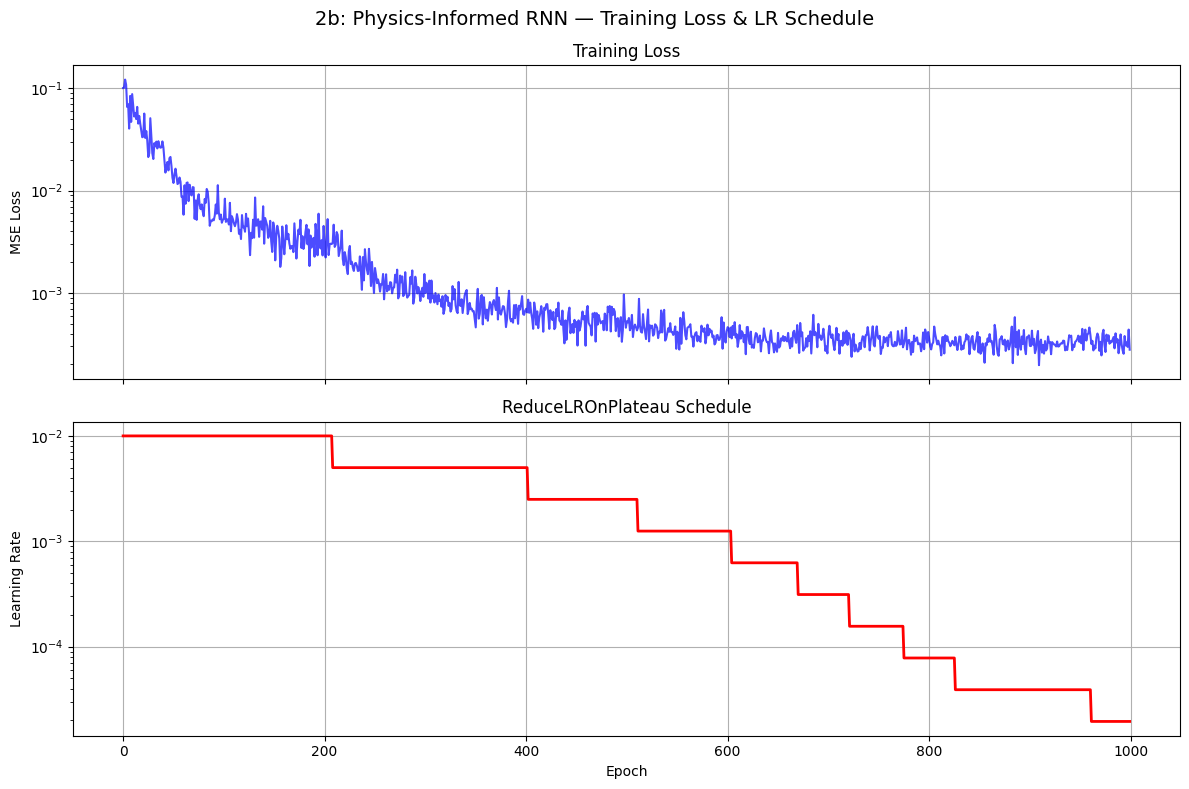

In [42]:
# Plot training loss + LR schedule for 2b
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
fig.suptitle("2b: Physics-Informed RNN — Training Loss & LR Schedule", fontsize=14)

ax1.plot(loss_2b, 'b-', alpha=0.7)
ax1.set_ylabel('MSE Loss')
ax1.set_title('Training Loss')
ax1.grid(True)
ax1.set_yscale('log')

ax2.plot(lr_2b, 'r-', lw=2)
ax2.set_ylabel('Learning Rate')
ax2.set_xlabel('Epoch')
ax2.set_title('ReduceLROnPlateau Schedule')
ax2.grid(True)
ax2.set_yscale('log')

plt.tight_layout()
plt.show()

Evaluating 2b autoregressively
2b TRAIN NSE — z1: 0.3480, z3: 0.1845
2b TEST  NSE — z1: 0.3993,  z3: 0.2010


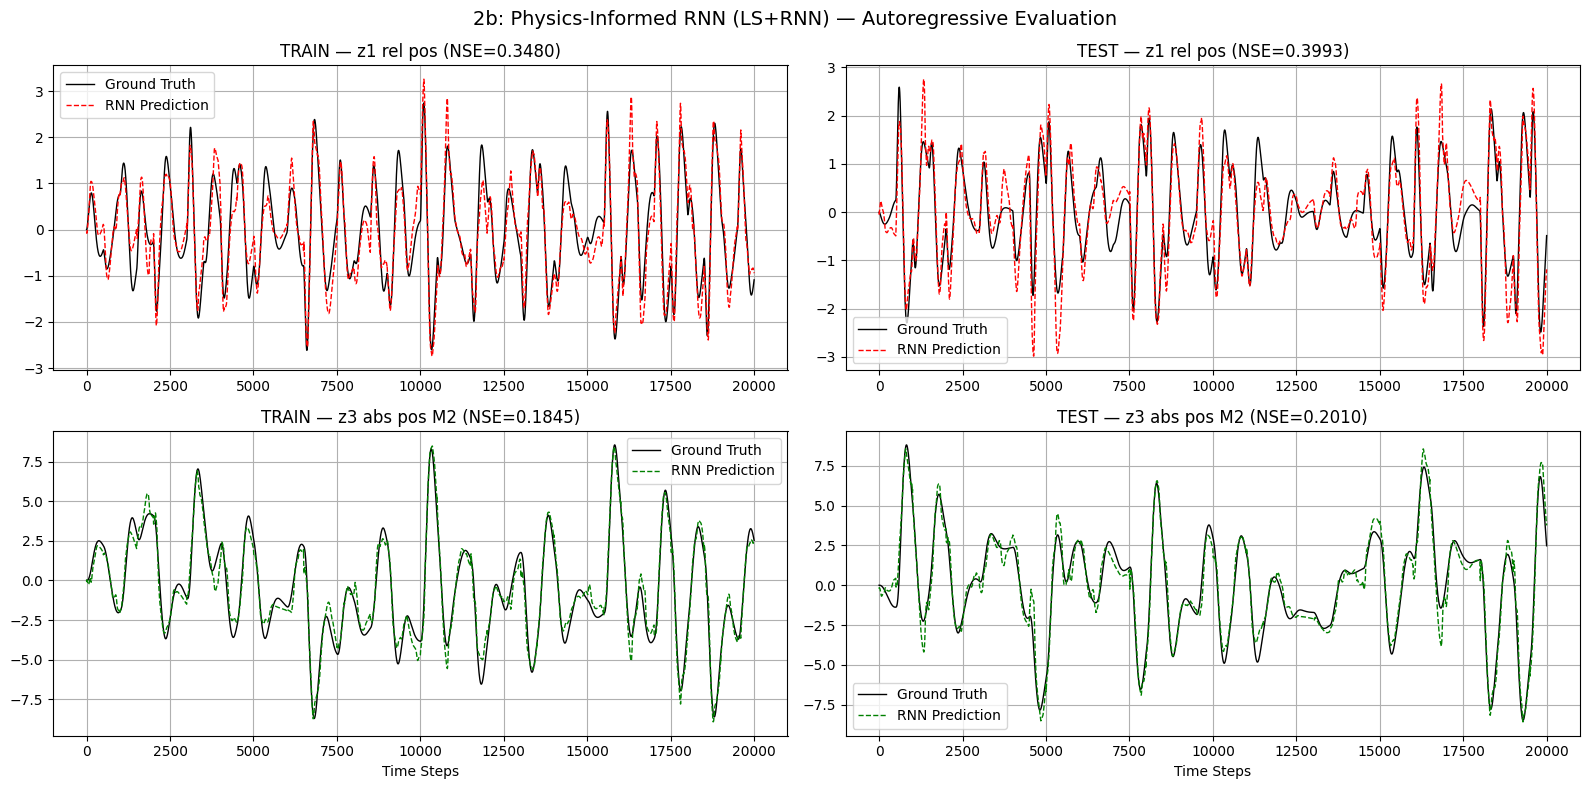

In [43]:
# --- Evaluate 2b: Autoregressive with on-the-fly LS predictions ---
# Key difference: during autoregressive rollout, the LS prediction must be 
# computed from the RNN's own predicted state (not ground truth), matching
# what we'd do in real deployment.

D_t = torch.tensor(D_ls, dtype=torch.float32).to(device)
E1_t = torch.tensor(E1_ls, dtype=torch.float32).to(device)
E2_t = torch.tensor(E2_ls, dtype=torch.float32).to(device)
z_mean_t = torch.tensor(z_mean, dtype=torch.float32).to(device)
z_std_t = torch.tensor(z_std, dtype=torch.float32).to(device)
u_mean_t = torch.tensor(u_mean, dtype=torch.float32).to(device)
u_std_t = torch.tensor(u_std, dtype=torch.float32).to(device)

def evaluate_physics_informed(model, Z_data, U_data, LS_data):
    """Autoregressive rollout for physics-informed RNN (input_size=9)."""
    model.eval()
    with torch.no_grad():
        preds = []
        current_state_norm = Z_data[0].to(device)
        h_k = torch.zeros(model.hidden_size, device=device)
        
        for k in range(len(U_data)):
            u_k_norm = U_data[k].to(device)
            ls_k = LS_data[min(k+1, len(LS_data)-1)].to(device)
            step_data = torch.cat((current_state_norm, u_k_norm, ls_k))
            
            h_k = torch.relu(h_k @ model.W_hh + step_data @ model.W_uh + model.b_h)
            residual_pred = h_k @ model.W_hx + model.b_x
            next_state_pred = ls_k + residual_pred  # was ls_pred_norm, should be ls_k
            preds.append(next_state_pred)
            current_state_norm = next_state_pred
        
        Y_pred_norm = torch.stack(preds)
        Y_pred = Y_pred_norm.cpu().numpy() * z_std + z_mean
    
    return Y_pred

print("Evaluating 2b autoregressively")

# TRAIN rollout
y_pred_2b_train = evaluate_physics_informed(model_2b, Z_train, U_train, LS_train)
nse_2b_train_z1 = compute_nse(z_train[:, 0], y_pred_2b_train[:, 0])
nse_2b_train_z3 = compute_nse(z_train[:, 2], y_pred_2b_train[:, 2])

# TEST rollout
y_pred_2b_test = evaluate_physics_informed(model_2b, Z_test, U_test, LS_test)
nse_2b_test_z1 = compute_nse(z_test[:, 0], y_pred_2b_test[:, 0])
nse_2b_test_z3 = compute_nse(z_test[:, 2], y_pred_2b_test[:, 2])

print(f"2b TRAIN NSE — z1: {nse_2b_train_z1:.4f}, z3: {nse_2b_train_z3:.4f}")
print(f"2b TEST  NSE — z1: {nse_2b_test_z1:.4f},  z3: {nse_2b_test_z3:.4f}")

plot_results(z_train, y_pred_2b_train, z_test, y_pred_2b_test,
             (nse_2b_train_z1, nse_2b_train_z3), (nse_2b_test_z1, nse_2b_test_z3),
             "2b: Physics-Informed RNN (LS+RNN) — Autoregressive Evaluation")

---
# Comparison: Training Loss Curves (2a vs 2b)

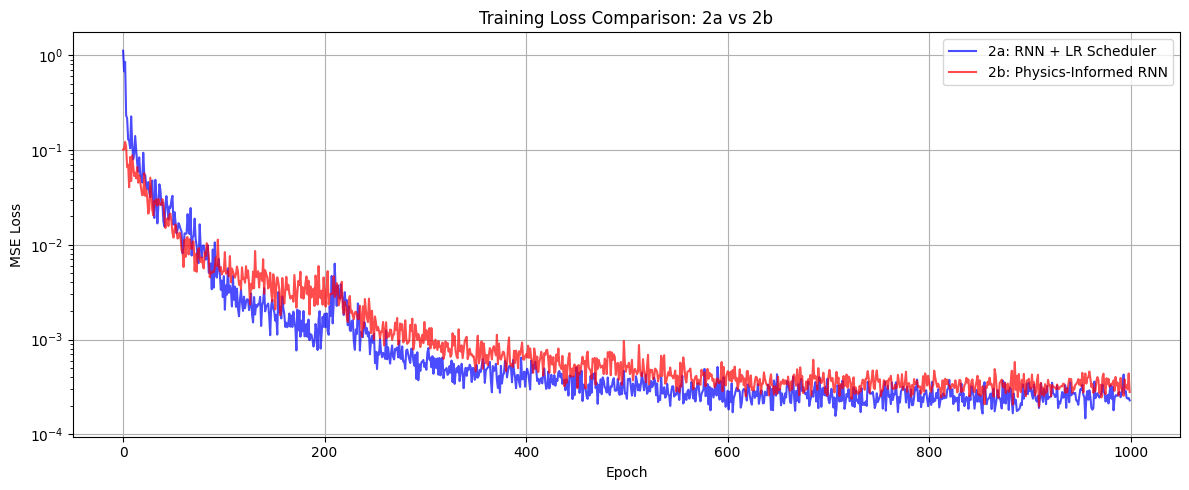

In [44]:
# Side-by-side training loss comparison
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(loss_2a, 'b-', alpha=0.7, label='2a: RNN + LR Scheduler')
ax.plot(loss_2b, 'r-', alpha=0.7, label='2b: Physics-Informed RNN')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.set_title('Training Loss Comparison: 2a vs 2b')
ax.set_yscale('log')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

---
# Summary: All NSE Results (LS Baselines + RNN Experiments)

Comparing everything on the **original ±1.0 nonlinear springs, transformed z-coordinates**:

In [45]:
# --- Final Summary Table ---
# Include LS baseline from Phase 1 for comparison
# (Recompute LS NSE here so the notebook is self-contained)

def rollout_ls_np(D, E1, E2, y0, u_plot, N):
    """Autoregressive LS rollout"""
    y_pred = np.zeros((N, 4))
    y_pred[0] = y0
    for k in range(N - 1):
        x_k = y_pred[k].reshape(4, 1)
        u_k_next = u_plot[k + 1] if k + 1 < N else u_plot[k]
        y_pred[k + 1] = (D @ x_k + E1 * u_k_next + E2 * u_plot[k]).flatten()
    return y_pred

# LS baseline rollouts
ls_rollout_train = rollout_ls_np(D_ls, E1_ls, E2_ls, z_train[0], u_train, len(u_train))
ls_rollout_test = rollout_ls_np(D_ls, E1_ls, E2_ls, z_test[0], u_test, len(u_test))

nse_ls_train_z1 = compute_nse(z_train[:, 0], ls_rollout_train[:, 0])
nse_ls_train_z3 = compute_nse(z_train[:, 2], ls_rollout_train[:, 2])
nse_ls_test_z1 = compute_nse(z_test[:, 0], ls_rollout_test[:, 0])
nse_ls_test_z3 = compute_nse(z_test[:, 2], ls_rollout_test[:, 2])

# Print summary
print("Autoregressive NSE — Original ±1.0 Springs (transformed z)")
print(f"\n{'Method':<45} {'Train z1':>8} {'Train z3':>8} {'Test z1':>8} {'Test z3':>8}")

results = {
    'LS Baseline (linear model)':         (nse_ls_train_z1, nse_ls_train_z3, nse_ls_test_z1, nse_ls_test_z3),
    '2a: CL ReLU h=64 + LR Scheduler':   (nse_2a_train_z1, nse_2a_train_z3, nse_2a_test_z1, nse_2a_test_z3),
    '2b: Physics-Informed RNN (LS+RNN)':  (nse_2b_train_z1, nse_2b_train_z3, nse_2b_test_z1, nse_2b_test_z3),
}

for name, (tr1, tr3, te1, te3) in results.items():
    print(f"{name:<45} {tr1:>8.4f} {tr3:>8.4f} {te1:>8.4f} {te3:>8.4f}")

print(f"\nLower NSE = better. NSE > 1.0 means the model is worse than predicting zero.")

Autoregressive NSE — Original ±1.0 Springs (transformed z)

Method                                        Train z1 Train z3  Test z1  Test z3
LS Baseline (linear model)                      0.3280   0.1827   0.4021   0.2158
2a: CL ReLU h=64 + LR Scheduler                 1.7476   1.7655   1.7450   1.5516
2b: Physics-Informed RNN (LS+RNN)               0.3480   0.1845   0.3993   0.2010

Lower NSE = better. NSE > 1.0 means the model is worse than predicting zero.
